# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import SymmetricalLogLocator
from matplotlib.path import Path
from scipy.interpolate import splprep, splev
from matplotlib.patches import PathPatch

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

In [4]:
import matplotlib as mpl

# FFT API

In [5]:
class Lf_analysis:
    def __init__(self, file, contact, is_exp_data=True):
        if is_exp_data:
            data = sl.pload(file_path, file)
            self.B_raw = data['ys'][0]
            self.Rxx_raw = data[f'sr830_{contact}_X']/data['sr830_4_X']
            Vtgs = data['xs'][0]
            Vbgs = data['xs'][1]
            self.density, self.D = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
        else:
            self.data = load_LL_simulation_data(file)
            self.density = self.data["ns_lin"][1:] # remove zero density
            fluxes = self.data["fluxes"]
            self.B_raw = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
            self.Rxx_raw = self.data["rhos_single_particle"][:,1:] # remove zero density
            
    # @lru_cache(maxsize=1)

    def get_bg_subtracted_data(self, bg_method, bg_method_params, blims, return_bg=False):
        """ 
            Do background subtraction on data 
            bg_method is function that takes in a row in B, Rxx and subtracts it
            blims is (low, high) bounds for B
        """
        # Limit our B
        blo, bhi = blims
        bmask = (blo < self.B_raw) & (self.B_raw < bhi)
        bflat = np.abs(np.diff(self.B_raw[bmask])) > 0 # get rid of parts where b is flat
        bmask[bmask] = bmask[bmask] & np.append(bflat, 1) & np.insert(bflat, 0, 1)
        B = self.B_raw[bmask] 
        Rxx_raw = self.Rxx_raw[bmask]    
        # Do a background subtraction on each line
        Rxx_detrended = np.zeros_like(Rxx_raw)
        for i, cut in enumerate(Rxx_raw.T):
            Rxx_detrended[:,i], _ = bg_method(B, cut, **bg_method_params)
        if return_bg:
            return B, Rxx_detrended, Rxx_raw - Rxx_detrended
        return B, Rxx_detrended

    # @lru_cache(maxsize=10)

    def get_fft(self, bg_method, bg_method_params, padding, blims, num_pts_max=5000):
        B, Rxx_detrended = self.get_bg_subtracted_data(bg_method, bg_method_params, blims)
        invB_range = np.max(1/B) - np.min(1/B)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/B)))))
        if num_invB_pts > num_pts_max:
            num_invB_pts = num_pts_max
        ffts = np.zeros((int(num_invB_pts*(2*padding+1)/2), len(self.density)), dtype=complex)
        freqs = np.zeros((int(num_invB_pts*(2*padding+1)/2), len(self.density)))
        for i, cut in enumerate(Rxx_detrended.T):
            interp_invB, interp_cut = interp_rxx(B, cut, nx=num_invB_pts, type='cubic')
            fft, freq = make_vec_fft(interp_invB, interp_cut, n=self.density[i], padding=padding, return_complex=True)
            ffts[:,i] = fft[:len(freq)//2]
            freqs[:,i] = freq[:len(freq)//2]

        return ffts, freqs
    
    def get_fft_line(self, target_density, bg_method, bg_method_params, padding, blims):
        # As get fft, but only get one line in density
        density_idx = np.argmin(np.abs(self.density-target_density))
        blo, bhi = blims
        bmask = (blo < self.B_raw) & (self.B_raw < bhi)
        bflat = np.abs(np.diff(self.B_raw[bmask])) > 0 # get rid of parts where b is flat
        bmask[bmask] = bmask[bmask] & np.append(bflat, 1) & np.insert(bflat, 0, 1)
        B = self.B_raw[bmask] 
        Rxx_raw = self.Rxx_raw[bmask, density_idx]        
        Rxx_detrended, _ = bg_method(B, Rxx_raw, **bg_method_params)
        invB_range = np.max(1/B) - np.min(1/B)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/B)))))
        interp_invB, interp_cut = interp_rxx(B, Rxx_detrended, nx=num_invB_pts, type='cubic')
        psd, freq = make_vec_fft(interp_invB, interp_cut, n=self.density[density_idx], padding=padding, normalize=False)
        psd = psd[:len(freq)//2]
        freq = freq[:len(freq)//2]
        return psd, freq

    @staticmethod
    def get_fft_peak(freq, fft, target_peak_val):
        # Given a cut in freq and peak, find peaks most closely matching target_peak_vals
        peaks, _ = find_peaks(np.abs(fft)**2, prominence=0.1)
        if len(peaks) < 1:
            return np.nan, np.nan
    
        peak_v = peaks[np.argmin(np.abs(freq[peaks] - target_peak_val))]
        
        return fft[peak_v], freq[peak_v]

    def plot_blim_effect(self, fig, ax, norm, bg_method, bg_method_params, padding, bhi_max, blo_min, target_density, target_freq, n_B_lims=60):
        min_window_len = 0.2

        b_mins = np.linspace(blo_min, 2.0, num=n_B_lims)
        b_maxes = np.linspace(blo_min+min_window_len, bhi_max, num=n_B_lims)

        fft_coefs_out = np.zeros((n_B_lims, n_B_lims)) * np.nan
        freqs_out = np.zeros((n_B_lims, n_B_lims)) * np.nan

        density_val = self.density[np.argmin(np.abs(self.density-target_density))]        
        for j, blo in enumerate(b_mins):
            for k, bhi in enumerate(b_maxes):
                if bhi - blo < min_window_len:
                    # Skip windows that are too small
                    fft_coefs_out[j,k], freqs_out[j,k] = np.nan, np.nan
                    continue
                
                psds, freqs = self.get_fft_line(target_density, bg_method, bg_method_params, padding, blims=(blo, bhi))
                fft, freq = self.get_fft_peak(freqs, psds, target_freq)
                fft_coefs_out[j,k], freqs_out[j,k] = np.abs(fft)**2, freq
        
        ax.set_facecolor('k')
        plot = ax.pcolormesh(
            b_mins, b_maxes, freqs_out.T*density_val,  rasterized=True,
            norm=norm, cmap='RdBu_r'
        )
        
        ax.set_xlabel("Low field cutoff (T)")
        ax.set_ylabel("High field cutoff (T)")
        return plot
    
    def plot_bw_filter_effect(self, fig, ax, norm, padding, target_density, target_freq, n_filters=60):
        min_window_len = 0.2

        filters = np.linspace(0, 50.0, num=n_filters)
        orders = np.arange(7, dtype=int)

        fft_coefs_out = np.zeros((n_filters, 7)) * np.nan
        freqs_out = np.zeros((n_filters, 7)) * np.nan

        density_val = self.density[np.argmin(np.abs(self.density-target_density))]        
        for j, filter_cutoff in enumerate(filters):
            for k, order in enumerate(orders):
              
                psds, freqs = self.get_fft_line(target_density, detrend_butterworth, {'cutoff': filter_cutoff, 'order': order}, padding, blims=(0.62, 4.98))
                fft_coefs_out[j,k], freqs_out[j,k] = self.get_fft_peak(freqs, psds, target_freq)
        
        ax.set_facecolor('k')
        plot = ax.pcolormesh(
            filters, orders, freqs_out.T*density_val,  rasterized=True,
            norm=norm, cmap='RdBu_r'
        )
        
        ax.set_xlabel(r"Filter Cutoff ($T^{-1}$)")
        ax.set_ylabel("Filter Order")
        return plot

    def plot_fft(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        psds = np.abs(ffts)**2
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))

        plot = ax.pcolormesh(density_repeated, freqs, psds, norm=norm, cmap='viridis', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(nh/e)$')
        ax.set_ylim(0, 3)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq = psds[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f)

        return plot
    
    def plot_fft_invcm(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))
        # Grey out freq cutoff
        psds = np.abs(ffts)**2
        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, psds, norm=norm, cmap='viridis', rasterized=True, lw=0)
        
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 2)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq =  psds[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f*self.density[density_idx])
         
        return plot

    def plot_fft_invcm_phase(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        angles = np.angle(ffts, deg=True) %180
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.Normalize(vmin=0, vmax=180)

        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, angles, norm=norm, cmap='twilight', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 2)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq =  angles[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f*self.density[density_idx])
         
        return plot

    def plot_fft_grad(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49)):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        psds = np.abs(ffts)**2
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        # def fft_deriv(linecut):
        #     # derivative down to a constant
        #     N = 6*len(linecut)
        #     fft = scipy.fft.rfft(linecut, n=N)
        #     freq = scipy.fft.rfftfreq(N)
        #     return scipy.fft.irfft(1j*freq*fft)[:len(linecut)]
            
        # deriv = np.apply_along_axis(fft_deriv, 0, psds)
        deriv = np.gradient(psds, axis=0)
        # deriv /= np.mean(np.abs(deriv), axis=0)
        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, 1/np.abs(deriv), norm=norm, cmap='viridis', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 3)
        return plot, deriv

    def get_peak_locs(self, fig, ax, bg_method, bg_method_params, padding, blims=(0.51, 2.49), density_lims=(0.35, 0.65)):
        nlo, nhi = density_lims
        density_mask = (nlo < self.density) & (self.density < nhi)
        target_peaks = np.array([1.155, 0.925])/self.density[density_mask,np.newaxis]

        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        peaks_out = np.zeros_like(target_peaks)
        peaks_coefs = np.zeros_like(target_peaks, dtype=complex)
        for i, (density, peaks, fft, freq) in enumerate(zip(self.density[density_mask], target_peaks, ffts.T, freqs.T)):
            for j, peak in enumerate(peaks):
                ft, fr = self.get_fft_peak(freq, fft, peak)
                peaks_out[i,j] = fr*density # Output freq in 10^12 cm-2
                peaks_coefs[i,j] = ft
        ax.plot(self.density[density_mask], peaks_out[:,0], '.')
        ax.plot(self.density[density_mask], peaks_out[:,1], '.')
        return plot, peaks_out, peaks_coefs

# a - Mapping phase boundary around CSC

['/home/aaron/Fermiology-and-the-cCSC/figs/fig4_gatemap_1479.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig4_gatemap_1479.png']

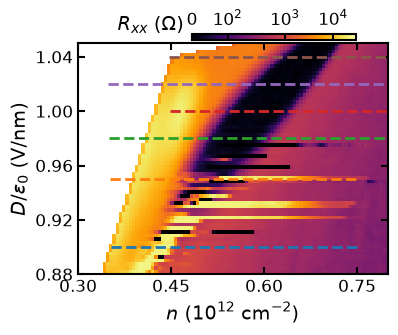

In [6]:
def plot_csc_gatemap_1479(ax, norm, cmap="viridis", interpolate=False):
    file= 1479
    ns = np.array([0.45, 0.72, 0.8, 0.8, 0.28])
    Ds = np.array([1.04, 1.065, 1.058, 0.80, 0.80])

    nx, ny = 101, 101
   
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    
    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)

    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long1': {'indices': [1,], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
 
    }
    
    gates = False
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            # load in the new data
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            xs = data['xs'][0] # top gate
            ys = data['xs'][1] # back gate
            phase = data[f'sr830_{ind}_P']
            phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
    
            if pair=='curr':
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                zs= I/(md['comments'][1]['I_ac']*1E-9)
            else:
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
            
            mask = np.abs(I) < 0.9 * 1E-9
            zs = np.ma.array(zs, mask=mask)
            xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
            xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=True)
            xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=True)
            xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 0, rev_x=False, rev_y=True)

            plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0, shading="auto")

            finite = np.isfinite(I)
            mask = np.abs(I) < 0.8 * np.nanmax(I)
            zs_m = np.ma.array(np.ones(zs.shape), mask=~mask  | ~finite)
            gray_cmap = colors.ListedColormap(["0.6"])
            ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)

            #ax.set_xlim(0.45, 0.75)
            #ax.set_ylim(0.9, 1.05)
            ax.set_xlim(0.3, 0.8)
            ax.set_ylim(0.88, 1.05)
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')

            #ax.scatter(0.59, 1, s=50, marker="D", color="gold")
            #ax.scatter(0.6, 1.01, s=50, marker="o", color="green")
            Ds = [0.9, 0.95, 0.98, 1.0, 1.02, 1.04]
            cs = [c for c in mpl.colormaps["tab10"].colors]
            nlims = [
                (0.35363096345260286,0.7518384781027235),
                (0.35115448838607466,0.7493620030361944),
                (0.3496686033461571,0.8474279966588077),
                (0.4482298919820763,0.846437406632196),
                (0.34768742329293284,0.8952227559368499),
                (0.44624871192885296,0.9240977295089976),
            ]
            for i, D in enumerate(Ds):
               ax.plot([nlims[i][0],nlims[i][1]],[D,D], ls="--", lw=2,c=cs[i], label = str(D) + " V/nm")
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))

            return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=150, vmin=0, vmax=3E4)
plot = plot_csc_gatemap_1479(ax, norm, "inferno", interpolate=False)

cax = fig.add_axes([0.41, 0.89, 0.41, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-15, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, "fig4_gatemap_1479")

In [7]:
def smooth_boundary(points, smoothing=0, n_interp=200, **patch_kwargs):
    """
    Create a smooth closed boundary through a set of points.

    Parameters
    ----------
    points : (N, 2) array-like
        Points on the boundary, in order (clockwise or counterclockwise).
    smoothing : float
        Spline smoothing factor s. 0 = interpolate through all points exactly;
        increase to relax the fit (useful for noisy/dense points).
    n_interp : int
        Number of points used to sample the smooth curve.
    **patch_kwargs
        Passed to PathPatch (e.g. facecolor, edgecolor, alpha, lw).

    Returns
    -------
    patch : matplotlib.patches.PathPatch
        Add to an Axes with ax.add_patch(patch).
    """
    pts = np.asarray(points, dtype=float)
    x, y = pts[:, 0], pts[:, 1]

    # per=1 makes the spline periodic (closed loop)
    tck, _ = splprep([x, y], s=smoothing, per=1)
    u = np.linspace(0, 1, n_interp)
    xs, ys = splev(u, tck)

    verts = np.column_stack([xs, ys])
    path = Path(verts, closed=True)
    return PathPatch(path, **patch_kwargs)

/tmp/ipykernel_757854/1881672894.py:46: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


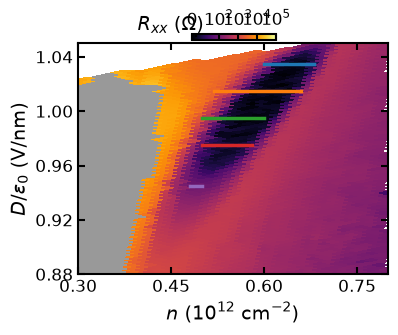

In [8]:
def plot_exp_nD(fig, ax, norm, cmap):
    file= 1354
    nx, ny = 201, 201

    ns = np.array([0.18, 0.8, 0.8, 0.18])
    Ds = np.array([1.016, 1.058, 0.60, 0.60])
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    
    verts = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts.append([Vtg, Vbg])
    
    verts = np.array(verts)
    
    contact_pairs = {
        'long1': {'indices': [1,], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    gates = False
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            # load in the new data
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            xs = data['xs'][0] # top gate
            ys = data['xs'][1] # back gate
            phase = data[f'sr830_{ind}_P']
            phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
    
            if pair=='curr':
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                zs= I/(md['comments'][1]['I_ac']*1E-9)
            else:
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                
                mask = np.abs(I) < 0.8 * 1E-9
                zs = np.ma.array(zs, mask=mask)
    
            xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 0, rev_x=False, rev_y=False)
            xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=False)
            xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 0, rev_x=False, rev_y=False)

            if not gates:
                xs, ys = calculate_n_D(xs, ys, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
                ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
                ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            else:
                ax.set_ylabel(r'$V_{Si}$ (V)')
                ax.set_xlabel(r'$V_{bg}$ (V)')
    
            plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)

            #finite = np.isfinite(I)
            mask = np.abs(I) < 0.90 * np.nanmax(I)
            #mask = np.abs(zs) > 1e4
            zs_m = np.ma.array(np.ones(zs.shape), mask=~mask)
            gray_cmap = colors.ListedColormap(["0.6"])
            ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)
           
            for a in [ax]:
                a.set_xlim(0.3, 0.8)
                a.set_ylim(0.88, 1.05)
                # a.axvline(0.18)
    
            Ds = [0.9, 0.95, 0.98, 1.0, 1.02, 1.04]
            cs = [c for c in mpl.colormaps["tab10"].colors]
            nlims = [
                (0.35363096345260286,0.7518384781027235),
                (0.35115448838607466,0.7493620030361944),
                (0.3496686033461571,0.8474279966588077),
                (0.4482298919820763,0.846437406632196),
                (0.34768742329293284,0.8952227559368499),
                (0.44624871192885296,0.9240977295089976),
            ]
            #for i, D in enumerate(Ds):
            #   ax.plot([nlims[i][0],nlims[i][1]],[D,D], ls="--", lw=2,c=cs[i], label = str(D) + " V/nm")
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=50, vmin=0, vmax=1E5)
plot = plot_exp_nD(fig, ax, norm, "inferno")

cax = fig.add_axes([0.41, 0.89, 0.21, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-15, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  

csc_pts = [[0.47, 0.95], [0.48, 0.96], [0.54,  1], [0.64, 1.04], [0.71, 1.05], [0.69, 1.04], [0.62, 1], [0.60, 0.96]]

patch = smooth_boundary(
        csc_pts,
        n_interp=100,
        smoothing=0.0,
        facecolor="white",
        edgecolor="gray",
        alpha=0.3,
        lw=1.5,
        ls="--",
        zorder = 2
        )
# ax.add_patch(patch)


sc_ranges = [
(0.60, 0.68),   # brown
(0.52, 0.66),   # purple
(0.50, 0.60),   # red
(0.50, 0.58),   # green
(0.48, 0.50),   # orange
(0.42, 0.42),   # blue — no clear SC pocket
]
Ds = [1.035,1.015, 0.995, 0.975, 0.945, 0.895]

for ind, D in enumerate(Ds):
    ax.plot([sc_ranges[ind][0], sc_ranges[ind][1]], [D, D])

1.0349422062514158
1.0150439937384677
0.9951133459733648
0.9752435143060525
0.945418494772487
0.8956425554412218


['/home/aaron/Fermiology-and-the-cCSC/figs/fig4_fft_all.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig4_fft_all.png']

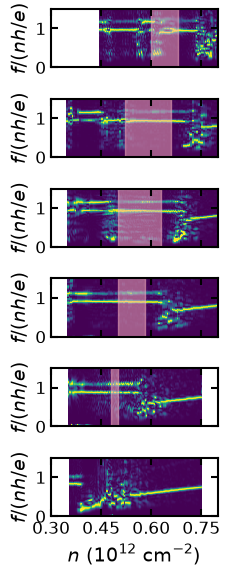

In [9]:
def plot_fft(fig, ax, norm, cmap, file):
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    ffts, freqs = analyzer.get_fft(bg_method=detrend_butterworth, \
                                              bg_method_params={'cutoff': None, 'order' : 4}, 
                                              padding=2, blims=(1, 4))
    print(analyzer.D[0])

    xs_repeated = np.tile(n_vec, (freqs.shape[0], 1))
    unnorm_freqs = np.array([f*n_vec for f in freqs])
    psds = np.abs(ffts)**2

    norm_skip_fraction = 0.03 # how much of the low freq to skip to find max
    norm_psds = np.array([p/(p[int(norm_skip_fraction*psds.T[0].shape[0]):].max()) for p in psds.T])
    plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)
    #ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$f/(nh/e)$')
    ax.set_ylim(0, 1.5)
    ax.set_yticks([0, 1])
    ax.set_xlim(0.3, 0.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))

    return plot


file_ids = [1885, 1957, 1840, 1958, 1886, 1888]
fig, axarr = plt.subplots(6, 1, figsize=(3, 1*6), sharex=True)  # sharex hides inner x-tick labels
norm = colors.SymLogNorm(linthresh=1, vmin=0, vmax=1)
cqm_boundary = [0.8, 0.75, 0.7, 0.67, 0.6, 0.53]
for ind, ax in enumerate(axarr):
    plot_fft(fig, ax, norm, "viridis", file_ids[ind])
    # ax.axvline(cqm_boundary[ind])
axarr[-1].set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')


sc_ranges = [
(0.60, 0.68),   
(0.52, 0.66),   
(0.50, 0.63),   
(0.50, 0.58),  
(0.48, 0.50),  
(0.42, 0.42),   
]

for ind, (n_lo, n_hi) in enumerate(sc_ranges):
    # skip last one
    if ind != len(sc_ranges) - 1:
        axarr[ind].axvspan(n_lo, n_hi, color="lightpink", alpha=0.5, zorder=1)
for ax in axarr:
    ax.set_box_aspect(0.35)  # pin panel shape so removing tick labels doesn't distort it (tune)
plt.tight_layout()
save_fig(fig, "fig4_fft_all")

['/home/aaron/Fermiology-and-the-cCSC/figs/fig4_phase_cartoon.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig4_phase_cartoon.png']

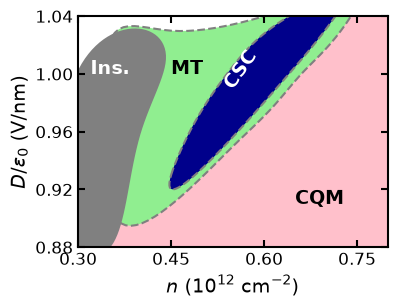

In [10]:
from matplotlib.path import Path
## cartoon of phase boundaries


def plot_phase_cartoon(fig, ax):
    
    cqm_pts = [[0.3, 0.88], [0.4,0.92], [0.62, 1.02], [0.68, 1.04], [1,1.04], [0.8, 0.88], [0.50, 0.88]]
    mt_pts = [[0.35, 0.92], [0.35,  0.94], [0.35, 1.02], [0.45, 1.03], 
               [0.5*(0.70 + 0.78), 1.04], # mt cqm boundary 
               [0.5*(0.66 + 0.75), 1.02], 
               [0.5*(0.60 + 0.72), 1], 
               [0.5*(0.57 + 0.67), 0.98], 
               [0.5*(0.50 + 0.6), 0.95], 
              [0.3, 0.9]] 
    csc_pts = [[0.45, 0.93], [0.48, 0.96], [0.54,  1], [0.64, 1.04], [0.73, 1.05], [0.715, 1.04], [0.64, 1], 
               [0.7, 0.96]]
    i_pts = [[0.3, 0.88], [0.3, 1.001], [0.44, 1.01], [0.40, 0.96], [0.35, 0.88], [0.32, 0.88]]
    
    facecolors = ["gray", "pink", "lightgreen", "darkblue"]    
    lss = ["-", "--", "--", "--"]
    zorders = [1, 0 ,0, 0]
    for ind, points in enumerate([i_pts, cqm_pts, mt_pts, csc_pts]):
        patch = smooth_boundary(
        points,
        n_interp=100,
        smoothing=0.0,
        facecolor=facecolors[ind],
        edgecolor="gray",
        alpha=1,
        lw=1.5,
        ls=lss[ind],
        zorder = zorders[ind]
        )
        ax.add_patch(patch)

    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))


fig = plt.figure(figsize=(4,3))
ax = plt.gca()

plot = plot_phase_cartoon(fig, ax)    
ax.text(0.32, 1.00, "Ins.", color="white", zorder=2, fontweight="bold")
ax.set_xlim(0.3, 0.8)
ax.set_ylim(0.88, 1.04)
ax.text(0.53, 0.99, "CSC", color="white", zorder=2, fontweight="bold", rotation=55,)
ax.text(0.45, 1.00, "MT", color="black", zorder=2, fontweight="bold")
ax.text(0.65, 0.91, "CQM", color="black", zorder=2, fontweight="bold")

save_fig(fig, "fig4_phase_cartoon")

# d - Onsager orbits

The functions are as follows
[8:23 PM]Circular (simply connected ) f(n) = 1
[8:24 PM]Annular
f(n) = 1 for n\geq n_c
f(n)_upper = n_c / n for n < n_c
f(n)_lower = 1-(n_c/n) for n < n_c[8:24 PM]3-pocket
f(n) = 1 for n\geq n_c
f(n) = 1/3 for n < n_c[8:26 PM]“Boomerang and Bean”
f(n) = 1 for n\geq n_c
f(n)_upper = -.4/n_c*(n-n_c) + .6 for n<n_c
f(n)_upper = .4/n_c*(n-n_c) + .4 for n < n_c[8:26 PM]The last one you can fiddle around with the .4 and .6 factors. You basically just want two lines that are not constant (edited) 
[8:27 PM]I’d recommend taking n_c = .5 and plotting between .25 and .75

/tmp/ipykernel_757854/104845728.py:14: RuntimeWarning: divide by zero encountered in divide
  ax.plot(n_vec[:len(n_vec)//2], nc/n_vec[:len(n_vec)//2], lw=lw, color=colors[1])
/tmp/ipykernel_757854/104845728.py:15: RuntimeWarning: divide by zero encountered in divide
  ax.plot(n_vec[:len(n_vec)//2], nc/n_vec[:len(n_vec)//2] - 1, lw=lw, color=colors[2])


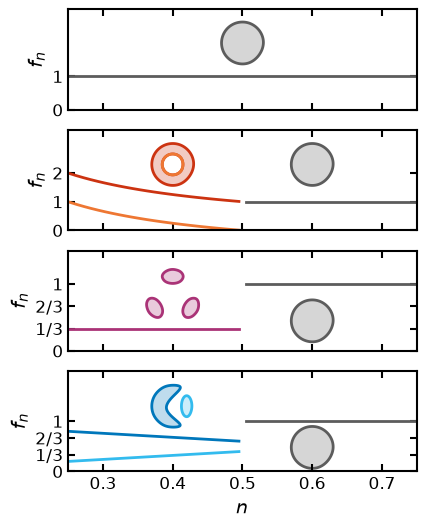

In [11]:
def plot_onsager(fig, axarr, colors, nc=0.5):
    """
    4 figures in a column
    """
    n_vec = np.linspace(0,1,100) # use only even number of points
    lw = 2
    ax = axarr[0]
    ax.plot(n_vec, 1*np.ones(len(n_vec)), color=colors[0], lw=lw)
    ax.set_ylim(0,3)
    ax.set_yticks([0,1])

    ax = axarr[1]
    ax.plot(n_vec[len(n_vec)//2:], 1*np.ones(len(n_vec)//2), lw=lw, color=colors[0])
    ax.plot(n_vec[:len(n_vec)//2], nc/n_vec[:len(n_vec)//2], lw=lw, color=colors[1])
    ax.plot(n_vec[:len(n_vec)//2], nc/n_vec[:len(n_vec)//2] - 1, lw=lw, color=colors[2])
    ax.set_ylim(0,3.5)
    ax.set_yticks([0,1,2])

    ax = axarr[2]
    ax.plot(n_vec[len(n_vec)//2:], 1*np.ones(len(n_vec)//2), color=colors[0], lw=lw)
    ax.plot(n_vec[:len(n_vec)//2], 1/3*np.ones(len(n_vec)//2), color=colors[3], lw=lw)
    ax.set_ylim(0,1.5)
    ax.set_yticks([0,1/3,2/3,1])
    ax.set_yticklabels(["0","1/3","2/3","1"])

    ax = axarr[3]
    ax.plot(n_vec[len(n_vec)//2:], 1*np.ones(len(n_vec)//2), color=colors[0], lw=lw)
    ax.plot(n_vec[:len(n_vec)//2], -0.4/nc * (n_vec[:len(n_vec)//2] - nc) + 0.6, color=colors[4], lw=lw)
    ax.plot(n_vec[:len(n_vec)//2], 0.4/nc * (n_vec[:len(n_vec)//2] - nc) + 0.4, color=colors[5], lw=lw)
    ax.set_ylim(0,2)
    ax.set_yticks([0,1/3,2/3,1])
    ax.set_yticklabels(["0","1/3","2/3","1"])
    ax.set_xlabel("$n$")

    for ind, ax in enumerate(axarr):
        ax.set_xlim(0.25, 0.75)
        ax.set_ylabel("$f_n$")

        if ind != len(axarr) - 1:
            ax.set_xticklabels([])
            ax.set_xlabel("")

    return


import importlib
import fermi_patches
importlib.reload(fermi_patches)

fig, axarr = plt.subplots(4,1, figsize=(4.5,6))
onsager_cmap = plt.colormaps['plasma']
onsager_colors = onsager_cmap(np.linspace(0.2,1,7))
onsager_colors = ["#5C5C5C", "#CC3311", "#EE7733", "#AA3377", "#0077BB", "#33BBEE", "#5C5C5C"]

plot_onsager(fig, axarr, onsager_colors)
# add this helper instead:


def fc(hex_color, alpha=0.25):
    r, g, b, _ = plt.matplotlib.colors.to_rgba(hex_color)
    return (r, g, b, alpha)


fermi_patches.add_patches(axarr[0], fermi_patches.make_circular_patch(
    axarr[0], center=(0.5, 2), radius=0.03,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[1], fermi_patches.make_circular_patch(
    axarr[1], center=(0.6, 2.3), radius=0.03,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[1], fermi_patches.make_annular_patch(
    axarr[1], center=(0.4, 2.3), outer_radius=0.03, inner_radius=0.015,
    facecolor=fc(onsager_colors[1]), outer_edgecolor=onsager_colors[1], inner_edgecolor=onsager_colors[2],
    lw=2))

fermi_patches.add_patches(axarr[2], fermi_patches.make_circular_patch(
    axarr[2], center=(0.6, 0.45), radius=0.03,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[2], fermi_patches.make_three_pocket_patch(
    axarr[2], center=(0.4, 0.8), orbit_radius=0.03, pocket_major=0.03,
    pocket_minor=0.02, start_angle=90, facecolor=fc(onsager_colors[3]), edgecolor=onsager_colors[3],
    lw=2))

fermi_patches.add_patches(axarr[3], fermi_patches.make_circular_patch(
    axarr[3], center=(0.6, 0.48), radius=0.03,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[3], fermi_patches.make_bean_pocket_patch(
    axarr[3], center=(0.4,1.3), bean_radius=0.03, gap_angle=70,
    pocket_major=0.03, pocket_minor=0.015, pocket_offset=(0.02, 0),
    bean_facecolor=fc(onsager_colors[4]), pocket_facecolor=fc(onsager_colors[5]),
    bean_edgecolor=onsager_colors[4], pocket_edgecolor=onsager_colors[5],
    lw=2))

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_757854/1009134847.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$n_{\mathrm{SdH}}$")


['/home/aaron/Fermiology-and-the-cCSC/figs/fig4_onsager_cartoon.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig4_onsager_cartoon.png']

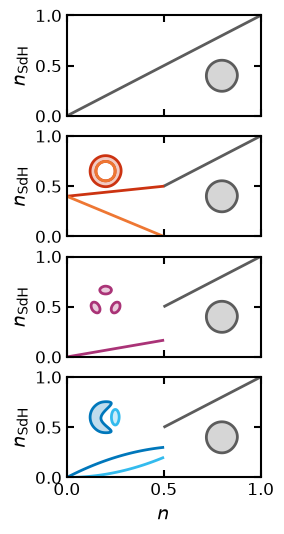

In [12]:
def plot_onsager_unnorm(fig, axarr, colors, nc=0.5):
    """
    4 figures in a column
    """
    n_vec = np.linspace(0,1,100) # use only even number of points
    lw = 2
    ax = axarr[0]
    ax.plot(n_vec, n_vec, color=colors[0], lw=lw)

    ax = axarr[1]
    ax.plot(n_vec[len(n_vec)//2:], n_vec[len(n_vec)//2:], lw=lw, color=colors[0])
    ax.plot(n_vec[:len(n_vec)//2], 0.8*nc*np.ones(len(n_vec)//2) + 0.2*n_vec[:len(n_vec)//2] , lw=lw, color=colors[1])
    ax.plot(n_vec[:len(n_vec)//2], 0.8*nc*np.ones(len(n_vec)//2) - 0.8*n_vec[:len(n_vec)//2], lw=lw, color=colors[2])

    ax = axarr[2]
    ax.plot(n_vec[len(n_vec)//2:], n_vec[len(n_vec)//2:], color=colors[0], lw=lw)
    ax.plot(n_vec[:len(n_vec)//2], 1/3*n_vec[:len(n_vec)//2], color=colors[3], lw=lw)

    ax = axarr[3]
    ax.plot(n_vec[len(n_vec)//2:], n_vec[len(n_vec)//2:], color=colors[0], lw=lw)
    ax.plot(n_vec[:len(n_vec)//2], (-0.4/nc * (n_vec[:len(n_vec)//2] - nc) + 0.6)*n_vec[:len(n_vec)//2], color=colors[4], lw=lw)
    ax.plot(n_vec[:len(n_vec)//2], (0.4/nc * (n_vec[:len(n_vec)//2] - nc) + 0.4)*n_vec[:len(n_vec)//2], color=colors[5], lw=lw)
    ax.set_xlabel("$n$")

    for ind, ax in enumerate(axarr):
        ax.set_xlim(0, 1)
        ax.set_ylim(0,1)
        ax.set_ylabel("$n_{\mathrm{SdH}}$")
        ax.set_yticks([0.0, 0.5, 1])
        ax.set_xticks([0.0, 0.5, 1])
        if ind != len(axarr) - 1:
            ax.set_xticklabels([])
            ax.set_xlabel("")

    return


import importlib
import fermi_patches
importlib.reload(fermi_patches)

fig, axarr = plt.subplots(4,1, figsize=(2.5,6))
onsager_cmap = plt.colormaps['plasma']
onsager_colors = onsager_cmap(np.linspace(0.2,1,7))
onsager_colors = ["#5C5C5C", "#CC3311", "#EE7733", "#AA3377", "#0077BB", "#33BBEE", "#5C5C5C"]

plot_onsager_unnorm(fig, axarr, onsager_colors)
# add this helper instead:


def fc(hex_color, alpha=0.25):
    r, g, b, _ = plt.matplotlib.colors.to_rgba(hex_color)
    return (r, g, b, alpha)


fermi_patches.add_patches(axarr[0], fermi_patches.make_circular_patch(
    axarr[0], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[1], fermi_patches.make_circular_patch(
    axarr[1], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[1], fermi_patches.make_annular_patch(
    axarr[1], center=(0.2, 0.65), outer_radius=0.08, inner_radius=0.05,
    facecolor=fc(onsager_colors[1]), outer_edgecolor=onsager_colors[1], inner_edgecolor=onsager_colors[2],
    lw=2))

fermi_patches.add_patches(axarr[2], fermi_patches.make_circular_patch(
    axarr[2], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[2], fermi_patches.make_three_pocket_patch(
    axarr[2], center=(0.2, 0.55), orbit_radius=0.06, pocket_major=0.06,
    pocket_minor=0.04, start_angle=90, facecolor=fc(onsager_colors[3]), edgecolor=onsager_colors[3],
    lw=2))

fermi_patches.add_patches(axarr[3], fermi_patches.make_circular_patch(
    axarr[3], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[3], fermi_patches.make_bean_pocket_patch(
    axarr[3], center=(0.2,0.6), bean_radius=0.08, gap_angle=70,
    pocket_major=0.08, pocket_minor=0.04, pocket_offset=(0.05, 0),
    bean_facecolor=fc(onsager_colors[4]), pocket_facecolor=fc(onsager_colors[5]),
    bean_edgecolor=onsager_colors[4], pocket_edgecolor=onsager_colors[5],
    lw=2))

save_fig(fig, "fig4_onsager_cartoon")

# Full figure

<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_757854/3150273827.py:79: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$n_{\mathrm{SdH}}$")
/tmp/ipykernel_757854/1881672894.py:46: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


1.0349422062514158
1.0150439937384677
0.9951133459733648
0.9752435143060525
0.945418494772487
0.8956425554412218


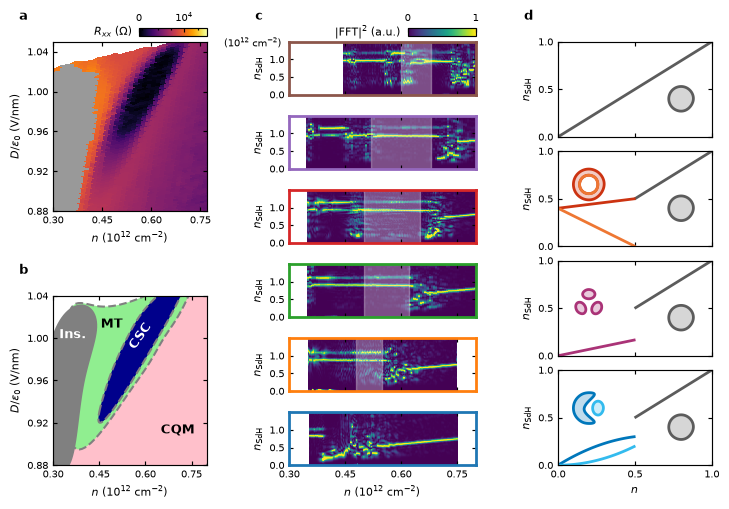

In [13]:
update_rc_params('paper')  # paper style for this final figure

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction (default; overridden locally)
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(8.5, 5.5))
gs = GridSpec(2, 3, figure=fig,   
                       width_ratios=[0.33, 0.4, 0.33],
                       height_ratios=[0.25, 0.25],
                       hspace=0.5, wspace=0.5)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')
norm = colors.SymLogNorm(linthresh=50, vmin=0, vmax=50E4)
plot = plot_exp_nD(fig, ax, norm, "inferno")
ax.set_xlim(0.3, 0.77)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100),
                  orientation='horizontal')
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticks([0, 10000])
cb.set_ticklabels(['0', '$10^4$'])

################ Panel c (inner grid) ##################
inner = GridSpecFromSubplotSpec(6, 1, subplot_spec=gs[0:2, 1], hspace=0.4, wspace=0.5,
                                width_ratios=[1])

norm = colors.Normalize(vmin=0, vmax=1)
cs = [c for c in mpl.colormaps["tab10"].colors][:len(file_ids)][::-1]
sc_ranges = [
    (0.60, 0.68),   # brown
    (0.52, 0.68),   # purple
    (0.50, 0.65),   # red
    (0.50, 0.62),   # green
    (0.48, 0.55),   # orange
    (0.42, 0.45),   # blue — no clear SC pocket
]
for ind, file_id in enumerate(file_ids):
    ax = fig.add_subplot(inner[ind, 0])
    plot = plot_fft(fig, ax, norm, "viridis", file_ids[ind])
    if ind == 0:
        fig.canvas.draw()  
        pos = ax.get_position()
        label_spacer = 0.04
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

        pos = ax.get_position()
        cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
        cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
        cb.ax.annotate(r'$|\mathrm{FFT}|^2$ (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
                       ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
        cb.ax.xaxis.set_ticks_position('top')
        cb.ax.xaxis.set_label_position('top')  

    if ind != len(file_ids) - 1:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor(cs[ind])

    ax.set_ylabel("$n_{\mathrm{SdH}}$")
    ax.set_yticks([0, 0.5, 1])

    n_lo, n_hi = sc_ranges[ind]
    if ind != len(file_ids) - 1:
        ax.axvspan(n_lo, n_hi, color="white", alpha=0.3, zorder=1)

    if ind == 0:
        ax.text(
            -0.35, 0.85,
            r'($10^{12}$ cm$^{-2}$)',
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=7,
        )

################ Panel b ##################
ax = fig.add_subplot(gs[1, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

plot = plot_phase_cartoon(fig, ax)    

ax.text(0.32, 1.00, "Ins.", color="white", zorder=2, fontweight="bold")
ax.set_xlim(0.3, 0.8)
ax.set_ylim(0.88, 1.04)
ax.text(0.54, 0.99, "CSC", color="white", zorder=2, fontweight="bold", rotation=55,)
ax.text(0.455, 1.01, "MT", color="black", zorder=2, fontweight="bold")
ax.text(0.65, 0.91, "CQM", color="black", zorder=2, fontweight="bold")
################ Panel d ##################
ax = fig.add_subplot(gs[0, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "d", fontweight='bold')
ax.axis("off")

onsager_axes = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[0:2, 2], hspace=0.15,
                                       wspace=0.5, width_ratios=[1])
line_colors = ["darkgreen", "tab:orange", "b", "tab:red", "tab:purple", "tab:brown"]
onsager_colors = onsager_cmap(np.linspace(0.2, 1, 7))
axarr = []
for ind in range(4):
    axarr.append(fig.add_subplot(onsager_axes[ind, 0]))
onsager_colors = ["#5C5C5C", "#CC3311", "#EE7733", "#AA3377", "#0077BB", "#33BBEE", "#5C5C5C"]
plot_onsager_unnorm(fig, axarr, onsager_colors)

fermi_patches.add_patches(axarr[0], fermi_patches.make_circular_patch(
    axarr[0], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[1], fermi_patches.make_circular_patch(
    axarr[1], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[1], fermi_patches.make_annular_patch(
    axarr[1], center=(0.2, 0.65), outer_radius=0.1, inner_radius=0.06,
    facecolor=fc(onsager_colors[1]), outer_edgecolor=onsager_colors[1],
    inner_edgecolor=onsager_colors[2], lw=2))

fermi_patches.add_patches(axarr[2], fermi_patches.make_circular_patch(
    axarr[2], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[2], fermi_patches.make_three_pocket_patch(
    axarr[2], center=(0.2, 0.55), orbit_radius=0.06, pocket_major=0.08,
    pocket_minor=0.06, start_angle=90, facecolor=fc(onsager_colors[3]),
    edgecolor=onsager_colors[3], lw=2))

fermi_patches.add_patches(axarr[3], fermi_patches.make_circular_patch(
    axarr[3], center=(0.8, 0.4), radius=0.08,   
    facecolor=fc(onsager_colors[0]), edgecolor=onsager_colors[0], lw=2))

fermi_patches.add_patches(axarr[3], fermi_patches.make_bean_pocket_patch(
    axarr[3], center=(0.2, 0.6), bean_radius=0.1, gap_angle=70,
    pocket_major=0.09, pocket_minor=0.07, pocket_offset=(0.06, 0),
    bean_facecolor=fc(onsager_colors[4]), pocket_facecolor=fc(onsager_colors[5]),
    bean_edgecolor=onsager_colors[4], pocket_edgecolor=onsager_colors[5], lw=2))

plt.show()
fig.savefig("fig4.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default